In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 14:36:25.808097


# neuron descriptive plots

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150
#sc.set_figure_params(scanpy=True)

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

# have to use the version of the dataset that has the transgenes to draw positive and negative signal

#bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheldß

In [6]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

In [13]:
adata.obs.output_id.value_counts()

output_id
TMA00311    19488
TMA00307     6911
TMA00308     6855
Name: count, dtype: int64

# Matrixplot

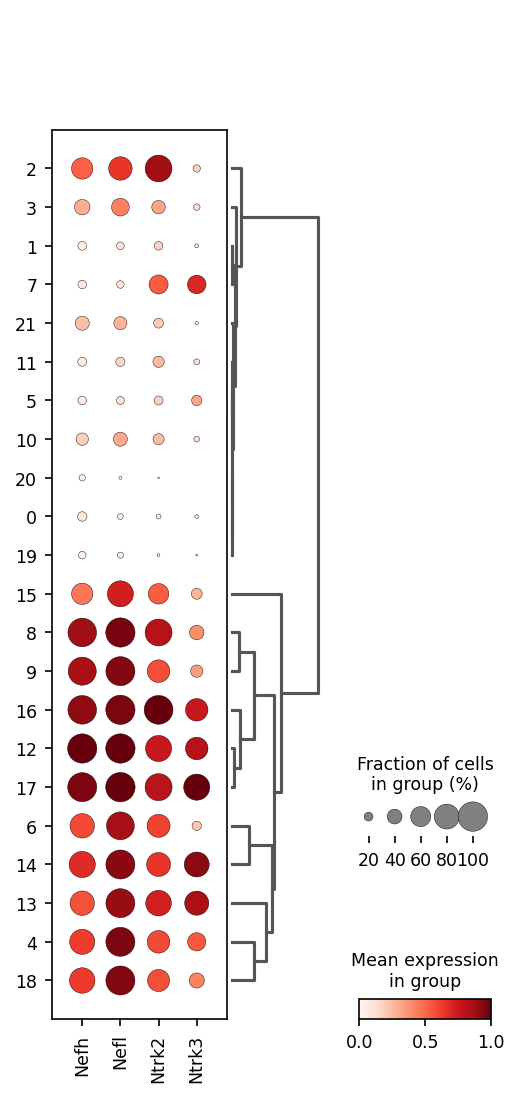

In [12]:
genes = ['Nefh', 'Nefl', 'Ntrk2', 'Ntrk3']
sc.pl.dotplot(adata, var_names = genes, groupby = 'leiden_scVI_1', standard_scale = 'var', dendrogram = True)

# Cell area